In [1]:
import pandas as pd
import numpy as np
from matplotlib_venn import venn2
import seaborn as sns
import matplotlib.pyplot as plt

### Supplementary Fig. 1B: comparison of vOTU recovery using two viral identification approaches

In [2]:
df_v1 = pd.read_csv('../data/all_viral-info.tsv', sep='\t', usecols=['votu_id','vir_len','method']).sort_values('vir_len', ascending=False).drop_duplicates(['votu_id','method'])

v_gmd = set(df_v1[df_v1.method == 'genomad'].votu_id.unique())
v_vs2 = set(df_v1[df_v1.method == 'vs2_checkv'].votu_id.unique())

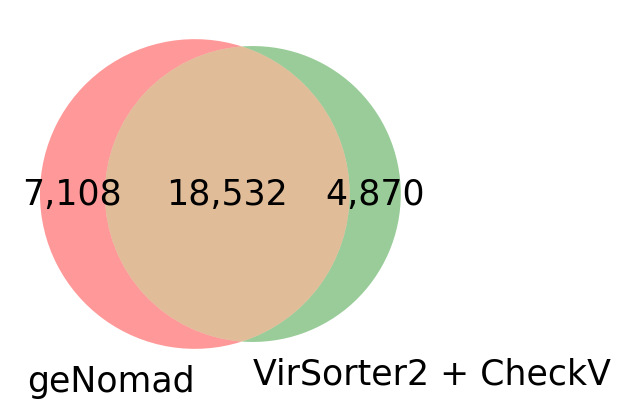

In [3]:
v2 = venn2([v_gmd, v_vs2], set_labels = ('geNomad', 'VirSorter2 + CheckV'))

fs=25
for text in v2.set_labels:
    text.set_fontsize(fs)

for text in v2.subset_labels:
    text.set_text(f"{int(text.get_text()):,}")
    text.set_fontsize(fs)

In [4]:
l = 200e3
long_votus = df_v1[df_v1.vir_len >= l].votu_id.unique()

v_gmd_long = set(df_v1[(df_v1.method == 'genomad') & df_v1.votu_id.isin(long_votus)].votu_id.unique())
v_vs2_long = set(df_v1[(df_v1.method == 'vs2_checkv') & df_v1.votu_id.isin(long_votus)].votu_id.unique())

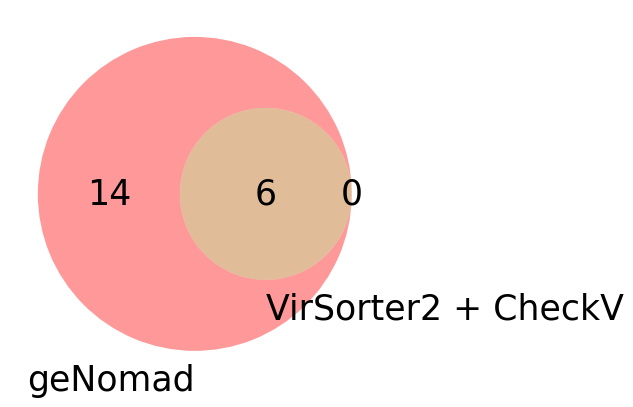

In [5]:
v2 = venn2([v_gmd_long, v_vs2_long], set_labels = ('geNomad', 'VirSorter2 + CheckV'))

fs=25
for text in v2.set_labels:
    text.set_fontsize(fs)

for text in v2.subset_labels:
    text.set_fontsize(fs)

### Supplementary Fig. 2A: vOTU length vs. CheckV quality tier distribution

In [6]:
df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','votu_len','checkv_quality','checkv_completeness_method','circular_unicycler'])

qualtiers = {'Not-determined': 0, 'Low-quality': 1, 'Medium-quality': 2, 'High-quality': 3, 'Complete': 4}
qualtiers2 = {v: k for k, v in qualtiers.items()}

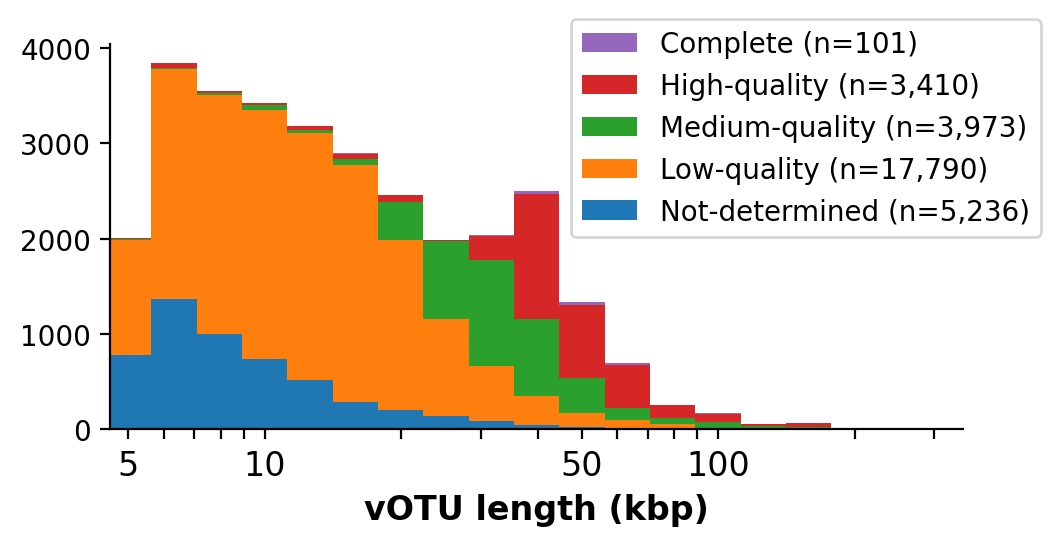

In [7]:
virs95ng = df_v.votu_id.tolist()
vir95ngtoqual = dict(zip(df_v['votu_id'], [qualtiers[q] for q in df_v['checkv_quality']]))
vir95ngtolen = dict(zip(df_v['votu_id'], df_v['votu_len']))

log10lens_quals = [[] for _ in range(5)]

for v in virs95ng:
    log10lens_quals[vir95ngtoqual[v]].append(np.log10(vir95ngtolen[v]))

n_quals = np.zeros((18, 5), dtype=int)
b_quals = np.zeros((19, 5))

for q in range(5):
    n, b = np.histogram(log10lens_quals[q], bins=np.arange(3.65, 5.55, 0.1))
    n_quals[:, q] = n
    b_quals[:, q] = b

fig, ax = plt.subplots(figsize=(5.5, 2.5), dpi=200)

for q in range(4, -1, -1):
    ax.bar(np.arange(3.7, 5.5, 0.1), n_quals[:, q], width=0.1, bottom=np.sum(n_quals[:, :q], axis=1),
           label=qualtiers2[q] + f' (n={len(df_v.loc[df_v.checkv_quality == qualtiers2[q]]):,})', color=f'C{q}', linewidth=0)

fs = 12
ax.set_xlabel("vOTU length (kbp)", fontsize=fs, fontweight='bold')

xtick_vals = np.log10(np.concatenate([np.arange(5000, 10001, 1000), np.arange(20000, 100001, 10000), np.arange(200000, 300001, 100000)]))
xtick_labels = ["5"] + [""] * 4 + ["10"] + [""] * 3 + ["50"] + [""] * 4 + ["100"] + [""] * 2
ax.set_xticks(xtick_vals)
ax.set_xticklabels(xtick_labels, fontsize=fs)
xmin, xmax = ax.set_xlim(3.66, None)

ax.legend(loc=(0.54,0.5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### Supplementary Fig. 2B: circular vOTUs identified by CheckV and Unicycler

In [8]:
v_checkv_complete = set(df_v[df_v.checkv_completeness_method.str.contains('DTR|ITR', na=False)].votu_id.tolist())
v_unicyc_complete = set(df_v[df_v.circular_unicycler == 'circular'].votu_id.tolist())

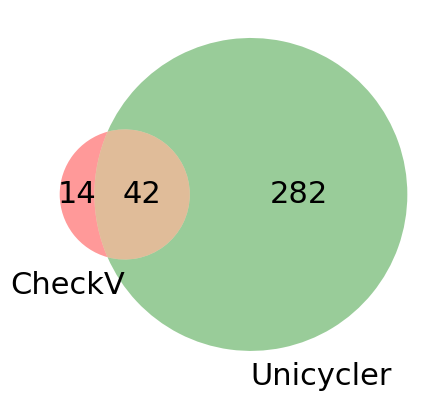

In [9]:
v2 = venn2([v_checkv_complete, v_unicyc_complete], set_labels = ('CheckV', 'Unicycler'))

fs=22
for text in v2.set_labels:
    text.set_fontsize(fs)

for text in v2.subset_labels:
    text.set_fontsize(fs)

### Supplementary Fig. 2C: CheckV quality distribution of Unicycler circular vOTUs

In [10]:
df_v_unicyc = df_v.loc[df_v.circular_unicycler == 'circular']

C:\Users\chenhr\AppData\Local\Temp\ipykernel_9860\277112902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_counts.index, y=quality_counts.values, order=[qualtiers2[i] for i in range(4,-1,-1)], palette=['C4','C3','C2','C1','C0'])


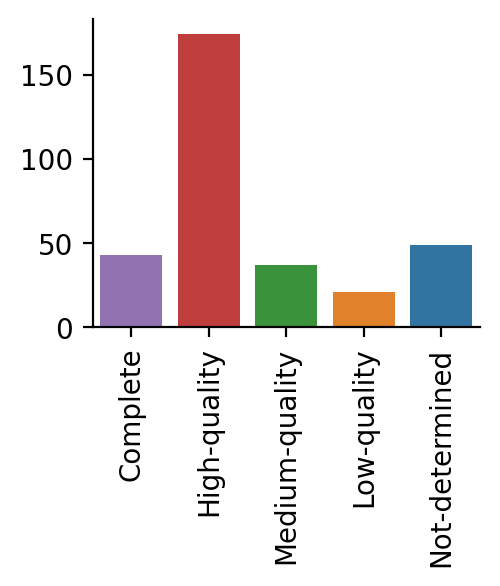

In [11]:
fig, ax = plt.subplots(figsize=(2.5, 2), dpi=200)

quality_counts = df_v_unicyc['checkv_quality'].value_counts()

sns.barplot(x=quality_counts.index, y=quality_counts.values, order=[qualtiers2[i] for i in range(4,-1,-1)], palette=['C4','C3','C2','C1','C0'])

plt.xticks(rotation=90)
plt.xlabel('')

sns.despine()